# Flipcart Laptop Price Analysis

## Data Loading

In [2]:
# import library
import pandas as pd
import numpy as np
import scipy
import matplotlib.pyplot as plt
import seaborn as sns

In [91]:
# Convert to dataframe
df = pd.read_excel("Flipkart-Laptops.xlsx")

# Top 5 observations
df.head()


,Product Name,ProductID,Product image,Actual price,Discount price,Stars,Rating,Reviews,Description,Link
0,MSI Cyborg 15 Intel Core i5 12th Gen 12450H - ...,COMGZW35W3DSJADN,NaN,89990,54990,3.9,7 Ratings,1 Reviews,Intel Core i5 Processor (12th Gen)16 GB DDR5 R...,https://www.flipkart.com/msi-cyborg-15-intel-c...
1,MSI Thin 15 Intel Core i7 12th Gen 12650H - (8...,COMGZW37ZX66DBHF,NaN,83990,67990,NIL,NIL,NIL,Intel Core i7 Processor (12th Gen)8 GB DDR4 RA...,https://www.flipkart.com/msi-thin-15-intel-cor...
2,DELL Inspiron 3520 Intel Core i3 12th Gen 1215...,COMGJ75HJGFDJ6JN,NaN,49240,35660,4.2,"1,805 Ratings",143 Reviews,Intel Core i3 Processor (12th Gen)8 GB DDR4 RA...,https://www.flipkart.com/dell-inspiron-3520-in...
3,Acer One (2024) Intel Core i3 11th Gen 1115G4 ...,COMGPF5CQ7VDWDT4,NaN,43999,26990,4.2,"6,977 Ratings",596 Reviews,Intel Core i3 Processor (11th Gen)8 GB DDR4 RA...,https://www.flipkart.com/acer-one-2024-intel-c...
4,Lenovo V15 AMD Ryzen 3 Quad Core 7320U - (8 GB...,COMGPYKZAWY8UX6C,NaN,59400,27989,4.2,"1,263 Ratings",113 Reviews,AMD Ryzen 3 Quad Core Processor8 GB LPDDR5 RAM...,https://www.flipkart.com/lenovo-v15-amd-ryzen-...


In [92]:
# Shape
print(df.shape)

# Basic information
df.info()

(960, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 960 entries, 0 to 959
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Product Name    960 non-null    object 
 1   ProductID       960 non-null    object 
 2   Product image   0 non-null      float64
 3   Actual price    960 non-null    object 
 4   Discount price  960 non-null    object 
 5   Stars           960 non-null    object 
 6   Rating          960 non-null    object 
 7   Reviews         960 non-null    object 
 8   Description     960 non-null    object 
 9   Link            960 non-null    object 
dtypes: float64(1), object(9)
memory usage: 75.1+ KB


**Comments:**

we can see that there are 960 observations and 10 columns. In Product image column there  no values are available, i.e., all are nan values. we can also observe that except Product image column, all columns are object type.

## Data cleaning and Preparation

In [93]:
# Remove white spaces from both sides of each column
df.columns = df.columns.str.strip()
df.columns

Index(['Product Name', 'ProductID', 'Product image', 'Actual price',
       'Discount price', 'Stars', 'Rating', 'Reviews', 'Description', 'Link'],
      dtype='object')

### Work with Price column

Let's first check 'Actual price' column contains how many NIL values 

In [6]:
# check the no. of NIL values
df['Actual price'].str.contains("NIL").sum()

7

In [7]:
round((df['Actual price'].str.contains("NIL").sum()/len(df['Actual price']))*100, 2)

0.73

**Comments:**

There are 7 NIL values that is less than 1%. So, we can drop those observations.

In [8]:
# Remove the "NIL" values from 'Actual price' column 
df = df[df['Actual price'] != "NIL"]

# Display first 3 observations
df.head(3)

,Product Name,ProductID,Product image,Actual price,Discount price,Stars,Rating,Reviews,Description,Link
0,MSI Cyborg 15 Intel Core i5 12th Gen 12450H - ...,COMGZW35W3DSJADN,NaN,89990,54990,3.9,7 Ratings,1 Reviews,Intel Core i5 Processor (12th Gen)16 GB DDR5 R...,https://www.flipkart.com/msi-cyborg-15-intel-c...
1,MSI Thin 15 Intel Core i7 12th Gen 12650H - (8...,COMGZW37ZX66DBHF,NaN,83990,67990,NIL,NIL,NIL,Intel Core i7 Processor (12th Gen)8 GB DDR4 RA...,https://www.flipkart.com/msi-thin-15-intel-cor...
2,DELL Inspiron 3520 Intel Core i3 12th Gen 1215...,COMGJ75HJGFDJ6JN,NaN,49240,35660,4.2,"1,805 Ratings",143 Reviews,Intel Core i3 Processor (12th Gen)8 GB DDR4 RA...,https://www.flipkart.com/dell-inspiron-3520-in...


In [9]:
# check nan values
df['Actual price'].isna().sum()

np.int64(0)

**Comments:**

we can see that "Discount Price" column contains 2 empty spaces values. So we remove it from "Discount Price" column.

In [10]:
# Take those values that are not empty like " "
df = df[df["Discount price"] != " "]

# Display first 3 observations of the data frame
df.head(3)

,Product Name,ProductID,Product image,Actual price,Discount price,Stars,Rating,Reviews,Description,Link
0,MSI Cyborg 15 Intel Core i5 12th Gen 12450H - ...,COMGZW35W3DSJADN,NaN,89990,54990,3.9,7 Ratings,1 Reviews,Intel Core i5 Processor (12th Gen)16 GB DDR5 R...,https://www.flipkart.com/msi-cyborg-15-intel-c...
1,MSI Thin 15 Intel Core i7 12th Gen 12650H - (8...,COMGZW37ZX66DBHF,NaN,83990,67990,NIL,NIL,NIL,Intel Core i7 Processor (12th Gen)8 GB DDR4 RA...,https://www.flipkart.com/msi-thin-15-intel-cor...
2,DELL Inspiron 3520 Intel Core i3 12th Gen 1215...,COMGJ75HJGFDJ6JN,NaN,49240,35660,4.2,"1,805 Ratings",143 Reviews,Intel Core i3 Processor (12th Gen)8 GB DDR4 RA...,https://www.flipkart.com/dell-inspiron-3520-in...


We know that **Actual Price** column and **Discount Price** column are Object type. For numerical computation, we need to convert those into float type.

In [11]:
#  Convert "Actual price" and "Discount price" columns datatype object to a float
df[["Actual price", "Discount price"]] = df[["Actual price", "Discount price"]].astype(float)

# Check tha data type
print(df["Actual price"].dtype)

# Check tha data type
print(df["Discount price"].dtype)

float64
float64


In [12]:
# Check the information about the data frame
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 953 entries, 0 to 959
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Product Name    953 non-null    object 
 1   ProductID       953 non-null    object 
 2   Product image   0 non-null      float64
 3   Actual price    953 non-null    float64
 4   Discount price  953 non-null    float64
 5   Stars           953 non-null    object 
 6   Rating          953 non-null    object 
 7   Reviews         953 non-null    object 
 8   Description     953 non-null    object 
 9   Link            953 non-null    object 
dtypes: float64(3), object(7)
memory usage: 81.9+ KB


Now create a new column called discount_pct for show the discount percentage amount for every laptop.

In [13]:
# Create "discount_pct(%)" column
df["discount_pct(%)"] = round(((df["Actual price"] - df["Discount price"]) / df["Actual price"]) * 100, 2)

# Display 5 observations of discount_pct(%) column
df["discount_pct(%)"].head()

0    38.89
1    19.05
2    27.58
3    38.66
4    52.88
Name: discount_pct(%), dtype: float64

#### 2. Product Image Column

We previously know that "Product image" column has all nan values. So this column is need not necessary for our analysis. So we can drop it from the dataframe.

In [14]:
# Drop the Product image column
df.drop(columns=["Product image"], inplace=True)

# Display first 5 observations
df.head()

,Product Name,ProductID,Actual price,Discount price,Stars,Rating,Reviews,Description,Link,discount_pct(%)
0,MSI Cyborg 15 Intel Core i5 12th Gen 12450H - ...,COMGZW35W3DSJADN,89990.0,54990.0,3.9,7 Ratings,1 Reviews,Intel Core i5 Processor (12th Gen)16 GB DDR5 R...,https://www.flipkart.com/msi-cyborg-15-intel-c...,38.89
1,MSI Thin 15 Intel Core i7 12th Gen 12650H - (8...,COMGZW37ZX66DBHF,83990.0,67990.0,NIL,NIL,NIL,Intel Core i7 Processor (12th Gen)8 GB DDR4 RA...,https://www.flipkart.com/msi-thin-15-intel-cor...,19.05
2,DELL Inspiron 3520 Intel Core i3 12th Gen 1215...,COMGJ75HJGFDJ6JN,49240.0,35660.0,4.2,"1,805 Ratings",143 Reviews,Intel Core i3 Processor (12th Gen)8 GB DDR4 RA...,https://www.flipkart.com/dell-inspiron-3520-in...,27.58
3,Acer One (2024) Intel Core i3 11th Gen 1115G4 ...,COMGPF5CQ7VDWDT4,43999.0,26990.0,4.2,"6,977 Ratings",596 Reviews,Intel Core i3 Processor (11th Gen)8 GB DDR4 RA...,https://www.flipkart.com/acer-one-2024-intel-c...,38.66
4,Lenovo V15 AMD Ryzen 3 Quad Core 7320U - (8 GB...,COMGPYKZAWY8UX6C,59400.0,27989.0,4.2,"1,263 Ratings",113 Reviews,AMD Ryzen 3 Quad Core Processor8 GB LPDDR5 RAM...,https://www.flipkart.com/lenovo-v15-amd-ryzen-...,52.88


In [15]:
df['Product Name']

0      MSI Cyborg 15 Intel Core i5 12th Gen 12450H - ...
1      MSI Thin 15 Intel Core i7 12th Gen 12650H - (8...
2      DELL Inspiron 3520 Intel Core i3 12th Gen 1215...
3      Acer One (2024) Intel Core i3 11th Gen 1115G4 ...
4      Lenovo V15 AMD Ryzen 3 Quad Core 7320U - (8 GB...
                             ...                        
954    Acer Predator Helios 300 (2024) Intel Core i7 ...
955    Acer Swift Go 14 (2024) AI Powered EVO Intel C...
957    Infinix X1 Slim Series (2024) Intel Core i3 10...
958    Lenovo IdeaPad Slim 3 Intel Core i5 12th Gen 1...
959    HP (15s-fq5007TU) Intel Core i3 12th Gen 1215U...
Name: Product Name, Length: 953, dtype: object

#### 3. Product Name Column
We know it contains all information about laptop.

Now we will extract information from it and create some other columns "processor", "ram_gb", "storage_gb", "storage_type".

In [16]:
import re

def extract_specs(name):
    specs = {}
    
    # Brand: first token
    specs['brand'] = name.split()[0]
    
    # CPU family: grab from Intel/AMD up to the next hyphen or opening parenthesis
    cpu_match = re.search(r'((?:Intel|AMD)[^-^(]+)', name, re.IGNORECASE)
    specs['processor'] = cpu_match.group(1).strip() if cpu_match else None
    
    # RAM size (first appearance of "NN GB" that is not storage)
    # We'll exclude matches immediately followed by SSD/HDD/EMMC
    ram_match = re.search(r'(\d+)\s*GB(?!\s*(?:SSD|HDD|EMMC))', name, re.IGNORECASE)
    specs['ram_gb'] = int(ram_match.group(1)) if ram_match else None
    
    # Storage: find all matches of capacity + unit + type
    stor_matches = re.findall(
        r'(\d+(?:\.\d+)?)\s*(GB|TB)\s*(SSD|HDD|EMMC)', 
        name, re.IGNORECASE
    )
    for size, unit, dtype in stor_matches:
        sz = float(size)
        if unit.upper() == 'TB':
            sz *= 1024
           
        specs['storage_gb'] = int(sz)
        specs['storage_type'] =  dtype.upper()

    return specs

# apply to DataFrame
extracted = df['Product Name'].apply(extract_specs).apply(pd.Series)

# Display first 5 observations of the extracted dataframe
extracted.head()

,brand,processor,ram_gb,storage_gb,storage_type
0,MSI,Intel Core i5 12th Gen 12450H,16.0,512.0,SSD
1,MSI,Intel Core i7 12th Gen 12650H,8.0,1024.0,SSD
2,DELL,Intel Core i3 12th Gen 1215U,8.0,512.0,SSD
3,Acer,Intel Core i3 11th Gen 1115G4,8.0,512.0,SSD
4,Lenovo,AMD Ryzen 3 Quad Core 7320U,8.0,512.0,SSD


In [17]:
extracted.info()

<class 'pandas.core.frame.DataFrame'>
Index: 953 entries, 0 to 959
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   brand         953 non-null    object 
 1   processor     932 non-null    object 
 2   ram_gb        952 non-null    float64
 3   storage_gb    944 non-null    float64
 4   storage_type  944 non-null    object 
dtypes: float64(2), object(3)
memory usage: 44.7+ KB


In [18]:
# Concatenate "df" and "extracted" dataframes
df = pd.concat([df, extracted], axis=1)

# Display first 5 observations
df.head()

,Product Name,ProductID,Actual price,Discount price,Stars,Rating,Reviews,Description,Link,discount_pct(%),brand,processor,ram_gb,storage_gb,storage_type
0,MSI Cyborg 15 Intel Core i5 12th Gen 12450H - ...,COMGZW35W3DSJADN,89990.0,54990.0,3.9,7 Ratings,1 Reviews,Intel Core i5 Processor (12th Gen)16 GB DDR5 R...,https://www.flipkart.com/msi-cyborg-15-intel-c...,38.89,MSI,Intel Core i5 12th Gen 12450H,16.0,512.0,SSD
1,MSI Thin 15 Intel Core i7 12th Gen 12650H - (8...,COMGZW37ZX66DBHF,83990.0,67990.0,NIL,NIL,NIL,Intel Core i7 Processor (12th Gen)8 GB DDR4 RA...,https://www.flipkart.com/msi-thin-15-intel-cor...,19.05,MSI,Intel Core i7 12th Gen 12650H,8.0,1024.0,SSD
2,DELL Inspiron 3520 Intel Core i3 12th Gen 1215...,COMGJ75HJGFDJ6JN,49240.0,35660.0,4.2,"1,805 Ratings",143 Reviews,Intel Core i3 Processor (12th Gen)8 GB DDR4 RA...,https://www.flipkart.com/dell-inspiron-3520-in...,27.58,DELL,Intel Core i3 12th Gen 1215U,8.0,512.0,SSD
3,Acer One (2024) Intel Core i3 11th Gen 1115G4 ...,COMGPF5CQ7VDWDT4,43999.0,26990.0,4.2,"6,977 Ratings",596 Reviews,Intel Core i3 Processor (11th Gen)8 GB DDR4 RA...,https://www.flipkart.com/acer-one-2024-intel-c...,38.66,Acer,Intel Core i3 11th Gen 1115G4,8.0,512.0,SSD
4,Lenovo V15 AMD Ryzen 3 Quad Core 7320U - (8 GB...,COMGPYKZAWY8UX6C,59400.0,27989.0,4.2,"1,263 Ratings",113 Reviews,AMD Ryzen 3 Quad Core Processor8 GB LPDDR5 RAM...,https://www.flipkart.com/lenovo-v15-amd-ryzen-...,52.88,Lenovo,AMD Ryzen 3 Quad Core 7320U,8.0,512.0,SSD


In [19]:
# Check the information about the data frame
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 953 entries, 0 to 959
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Product Name     953 non-null    object 
 1   ProductID        953 non-null    object 
 2   Actual price     953 non-null    float64
 3   Discount price   953 non-null    float64
 4   Stars            953 non-null    object 
 5   Rating           953 non-null    object 
 6   Reviews          953 non-null    object 
 7   Description      953 non-null    object 
 8   Link             953 non-null    object 
 9   discount_pct(%)  953 non-null    float64
 10  brand            953 non-null    object 
 11  processor        932 non-null    object 
 12  ram_gb           952 non-null    float64
 13  storage_gb       944 non-null    float64
 14  storage_type     944 non-null    object 
dtypes: float64(5), object(10)
memory usage: 119.1+ KB


**Comments:**

Now our new dataframe has 953 observations and 15 columns. You can clearly see that "Actual price", "Discount price", "discount_pct(%)", "ram_gb", "storage_gb" columns are all float type and others are all object type.

#### 4. Missing Data Handling

In [20]:
# Check how many null values contains each column of the dataframe df
df.isnull().sum()

Product Name        0
ProductID           0
Actual price        0
Discount price      0
Stars               0
Rating              0
Reviews             0
Description         0
Link                0
discount_pct(%)     0
brand               0
processor          21
ram_gb              1
storage_gb          9
storage_type        9
dtype: int64

In [21]:
# Check the % value 
((df["processor"].isnull().sum())/len(df))*100 + ((df["storage_gb"].isnull().sum())/len(df))*100 +((df["storage_type"].isnull().sum())/len(df))*100

np.float64(4.092339979013642)

In [22]:
# Drop null values
df.dropna(inplace=True)

# Check the information about the data frame
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 923 entries, 0 to 959
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Product Name     923 non-null    object 
 1   ProductID        923 non-null    object 
 2   Actual price     923 non-null    float64
 3   Discount price   923 non-null    float64
 4   Stars            923 non-null    object 
 5   Rating           923 non-null    object 
 6   Reviews          923 non-null    object 
 7   Description      923 non-null    object 
 8   Link             923 non-null    object 
 9   discount_pct(%)  923 non-null    float64
 10  brand            923 non-null    object 
 11  processor        923 non-null    object 
 12  ram_gb           923 non-null    float64
 13  storage_gb       923 non-null    float64
 14  storage_type     923 non-null    object 
dtypes: float64(5), object(10)
memory usage: 115.4+ KB


### EDA

#### Price Dynamics

In [23]:
# check the descriptive statistics of numeric values
df.describe()

,Actual price,Discount price,discount_pct(%),ram_gb,storage_gb
count,923.000000,923.000000,923.000000,923.000000,923.000000
mean,75354.066089,54495.817985,28.845330,11.813651,553.152763
std,36051.320904,31239.227218,9.862427,5.011045,218.346988
min,21990.000000,13990.000000,0.670000,4.000000,32.000000
25%,51967.000000,35990.000000,21.715000,8.000000,512.000000
50%,69890.000000,47990.000000,28.110000,8.000000,512.000000
75%,88990.000000,63990.000000,36.165000,16.000000,512.000000
max,499990.000000,439990.000000,60.020000,64.000000,2048.000000


**Comments:**

From the above scenario, we can observe that mean > median for `Actual price` and `Discount price` columns, so the distribution of `Actual price` and `Discount price` columns are right skewed. 

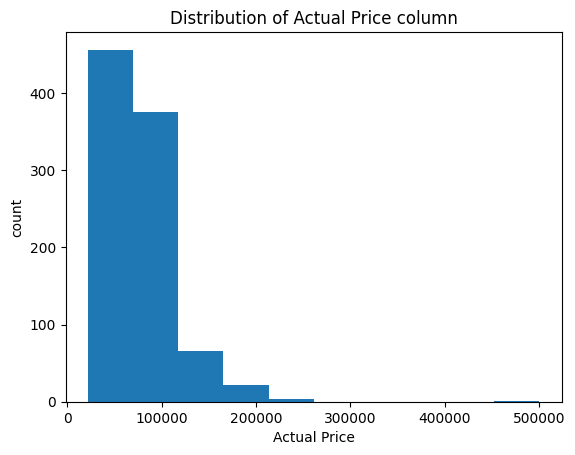

In [24]:
plt.figure()

# Plot a histogram of Actual price column
plt.hist(df["Actual price"])

# Add x-axis label
plt.xlabel("Actual Price")

# Add y-axis label
plt.ylabel("count")

# Add title
plt.title("Distribution of Actual Price column");

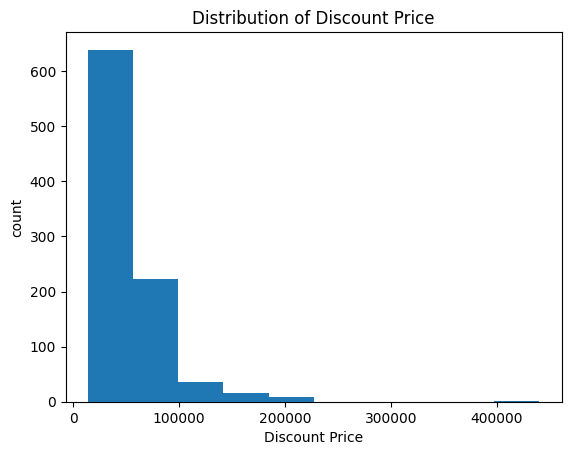

In [25]:
plt.figure()

# Plot a histogram of Actual price column
plt.hist(df["Discount price"])

# Add x-axis label
plt.xlabel("Discount Price")

# Add y-axis label
plt.ylabel("count")

# Add title
plt.title("Distribution of Discount Price");

### Analysis for brand

#### Total sale amount by each brand

In [26]:
# Check total discount price by each brand
brand_sell_price = df.groupby(["brand"])["Discount price"].sum().sort_values(ascending=False)
brand_sell_price

brand
MSI          12109351.0
HP           11047445.0
Lenovo        8801200.0
ASUS          7164594.0
Acer          3210626.0
Thomson       2833636.0
DELL          1969053.0
SAMSUNG       1022890.0
Infinix        863511.0
Colorful       509940.0
ZEBRONICS      259930.0
Avita          108462.0
realme          99989.0
CHUWI           96950.0
GIGABYTE        63990.0
Vaio            45042.0
Ultimus         37989.0
Mi              37052.0
AXL             17990.0
Name: Discount price, dtype: float64

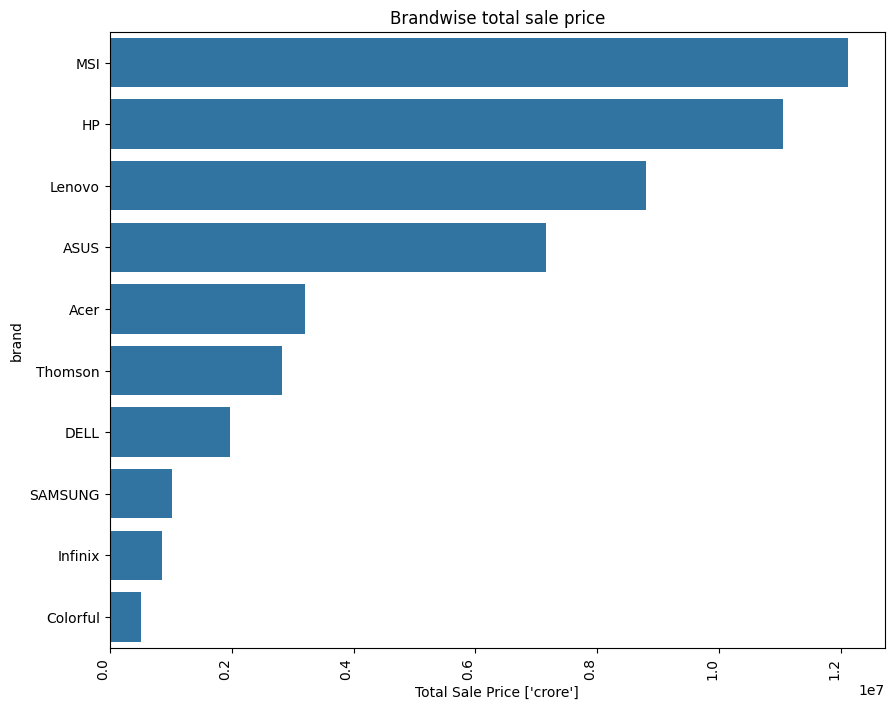

In [27]:
plt.figure(figsize=(10,8))

# Total sale amount of top 10 brands
sns.barplot(brand_sell_price.head(10), orient='h')
# Add xticks
plt.xticks(rotation=90, ha="right")

# Xlabel
plt.xlabel("Total Sale Price ['crore']")
# Add title
plt.title("Brandwise total sale price")

plt.show();

**Comments:**

From the above figure, we clearly observe that  `MSI, HP, Lenovo, ASUS` brands laptops has more total sale than other brand.

#### No of laptop sold by each brand

Text(0.5, 1.0, 'Top 10 brands having highest no of laptop solded')

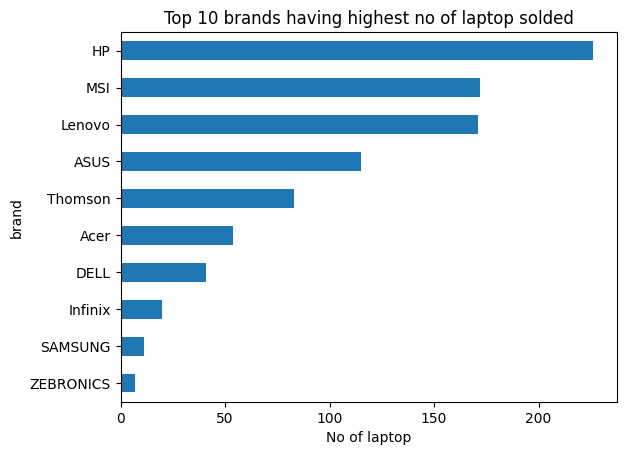

In [28]:
# Top 10 brand that sold highest no of laptops

df['brand'].value_counts(ascending=True).tail(10).plot(kind='barh')

# Xlabel
plt.xlabel("No of laptop")

# Title
plt.title("Top 10 brands having highest no of laptop solded")

#### Average selling price of laptop by each brand.

In [29]:
avg_laptop_price_brandwise = df.groupby(['brand'])["Discount price"].mean()
avg_laptop_price_brandwise

brand
ASUS         62300.817391
AXL          17990.000000
Acer         59456.037037
Avita        27115.500000
CHUWI        19390.000000
Colorful     84990.000000
DELL         48025.682927
GIGABYTE     63990.000000
HP           48882.500000
Infinix      43175.550000
Lenovo       51469.005848
MSI          70403.203488
Mi           37052.000000
SAMSUNG      92990.000000
Thomson      34140.192771
Ultimus      18994.500000
Vaio         45042.000000
ZEBRONICS    37132.857143
realme       49994.500000
Name: Discount price, dtype: float64

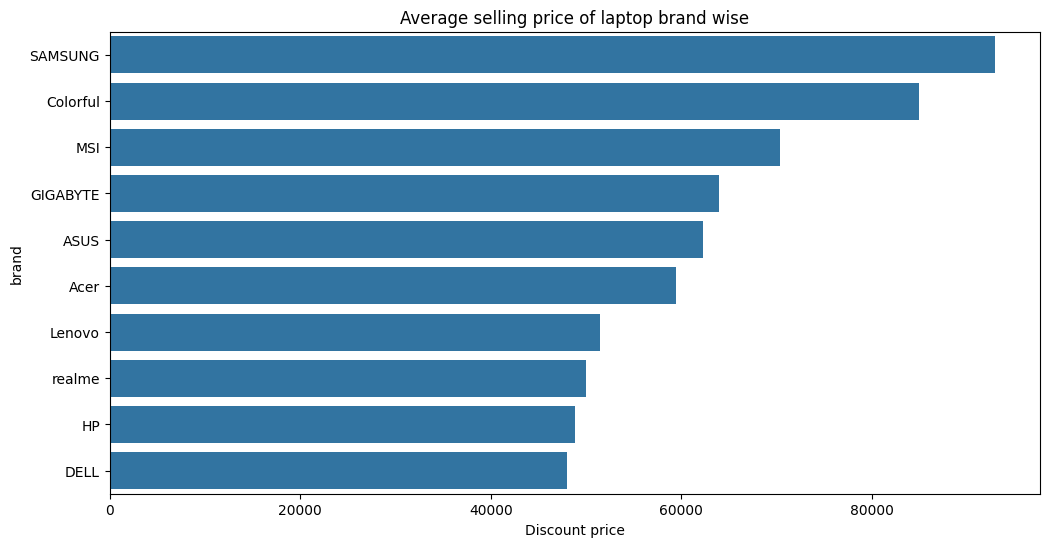

In [30]:
plt.figure(figsize=(12,6))

# Use catplot to see "average actual selling price of laptop" by top 10 brands
sns.barplot(data=avg_laptop_price_brandwise.sort_values(ascending=False).head(10), orient='h')

# Add title
plt.title("Average selling price of laptop brand wise")

plt.show();

**Comments:**

We can see from the above figure that `SAMSUNG, Colorful, MSI, GIGABYTE` brands avrage selling price is high more than other brands.

#### Top 20 most expensive laptops by brand

Text(0.5, 1.0, 'Top 20 most expensive laptops by brand')

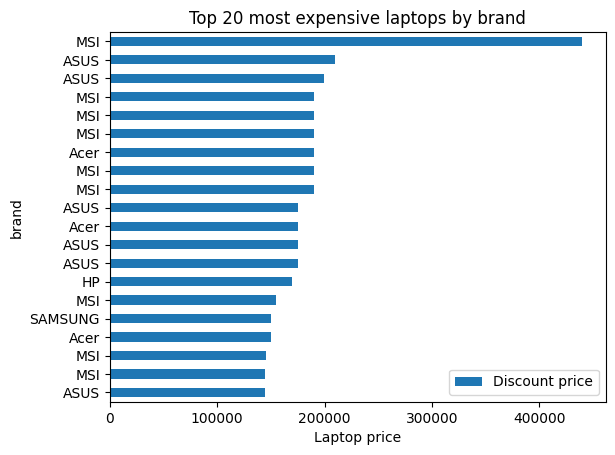

In [31]:
df[["brand", "Discount price"]].set_index(['brand']).sort_values(by="Discount price").tail(20).plot(kind='barh')

# xlabel
plt.xlabel("Laptop price")

# Title
plt.title("Top 20 most expensive laptops by brand")

**Comment:**

Its clear that MSI, ASUS, Acer, HP, Samsung sold highest expensive laptops.

#### Now let's find processor those are used in top 20 most expensive laptop

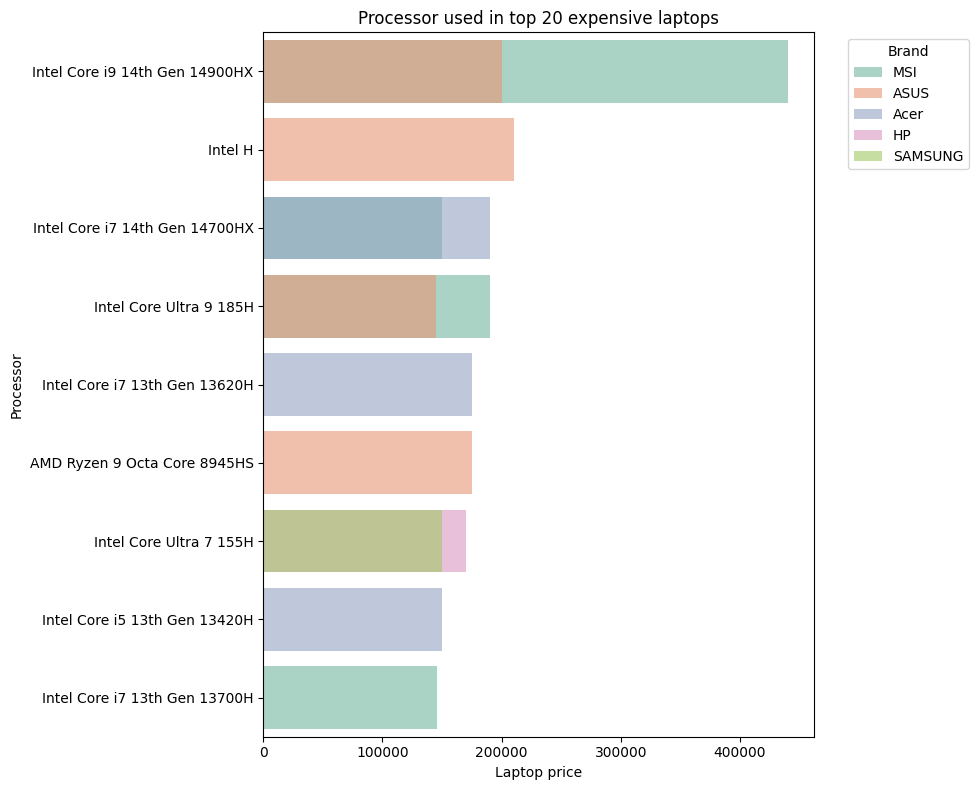

In [32]:
# Top 20 expensive laptop 
top20 = (
    df[["processor", "Discount price", "brand"]]
    .sort_values("Discount price", ascending=False)
    .head(20)
)

# Set your figure size (optional)
plt.figure(figsize=(10, 8))

# Draw a horizontal barplot, mapping 'brand' to the hue
sns.barplot(
    data=top20,
    x="Discount price",
    y="processor",
    hue="brand",
    alpha=0.6,
    errorbar=None,
    dodge=False,        # set to False so bars don’t get split by brand
    palette="Set2"  
)

# Labels and title
plt.xlabel("Laptop price")
plt.ylabel("Processor")
plt.title("Processor used in top 20 expensive laptops")

# Legend configuration (optional)
plt.legend(title="Brand", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

**Comment:**

Peoples bought most expensive laptop with intel processor 

In [33]:
## How processor affect the laptop price
avg_laptop_price_processorwise = (df.groupby(["processor"])["Discount price"].mean()).sort_values()
avg_laptop_price_processorwise 

processor
Intel Celeron Dual Core 10th Gen N4020     13990.0
Intel Celeron Dual Core 11th Gen N4020     17990.0
Intel Celeron Dual Core 9th Gen            17990.0
Intel Celeron Dual Core N3350              18890.0
Intel Celeron Quad Core 11th Gen N5100     19990.0
                                            ...   
Intel Core Ultra 7 1st Gen 155H           139990.0
AMD Ryzen 9 Octa Core 8945H               142990.0
Intel Core Ultra 9 185H                   171990.0
AMD Ryzen 9 Octa Core 8945HS              174990.0
Intel Core i9 14th Gen 14900HX            319990.0
Name: Discount price, Length: 163, dtype: float64

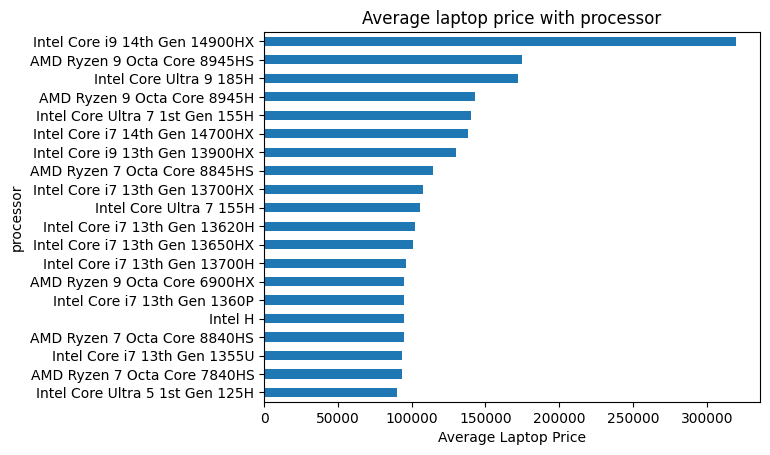

In [34]:
avg_laptop_price_processorwise.tail(20).plot(kind='barh')
plt.xlabel("Average Laptop Price")
plt.title("Average laptop price with processor");

**Comments:**

It's clear that with the increase of processor quality, laptop price also increase. So there is positive correletion between those.

### How RAM affects the laptop prices

In [35]:
# Average selling price of laptop for different GB RAM
avg_laptop_price_ramwise = (df.groupby(["ram_gb"])["Discount price"].mean()).reset_index()
avg_laptop_price_ramwise

,ram_gb,Discount price
0,4.0,21512.437500
1,8.0,41041.075594
2,12.0,62490.000000
3,16.0,68258.213592
4,24.0,99990.000000
5,32.0,162190.000000
6,64.0,439990.000000


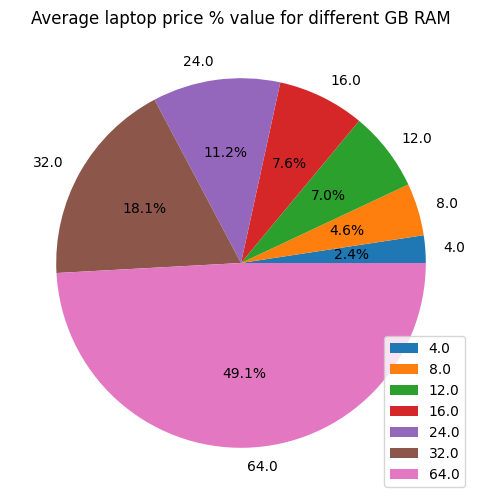

In [36]:
plt.figure(figsize=(12,6))

# Pie chart
plt.pie(x=avg_laptop_price_ramwise["Discount price"], labels=avg_laptop_price_ramwise["ram_gb"], autopct='%1.1f%%')
plt.title("Average laptop price % value for different GB RAM")

# Add legend
plt.legend(loc="lower right");

**Comments:**

From the above figure, it is clear that 64GB RAM highly affect the average laptop price i.e., laptop with 64 GB RAM are very expensive than 32 GB, 16 GB, etc laptops.

### How Storage volume affects the laptop price

In [37]:
# Average selling price for different storage type
avg_laptop_price_with_storageVolume = (df.groupby(["storage_gb"])["Discount price"].mean()).reset_index()

avg_laptop_price_with_storageVolume

,storage_gb,Discount price
0,32.0,18590.000000
1,64.0,18916.666667
2,128.0,19310.000000
3,256.0,32580.470588
4,512.0,50639.113537
5,1024.0,91686.915385
6,2048.0,439990.000000


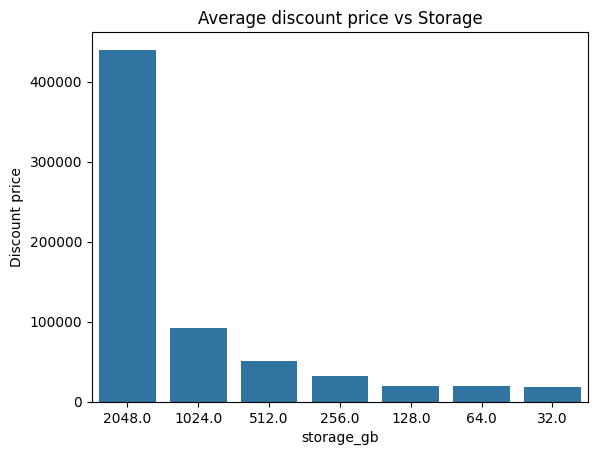

In [38]:
# Create xticks
xtick=avg_laptop_price_with_storageVolume["storage_gb"].unique()[::-1]

# Create a bar plot to show average selling price for different gb storage
sns.barplot(data=avg_laptop_price_with_storageVolume, x="storage_gb", y="Discount price", order=xtick)

# Add title
plt.title("Average discount price vs Storage");

**Comments:**

From figure we can see that storage volume highly affects the average laptop price. It is clear that laptop with 2048 GB storage has average price is greater than 400_000 lakh which is four times higher than laptop with 1024 GB.

#### How storage type affects the average laptop price

In [39]:
avg_laptop_price_with_storageType = df.groupby(["storage_type"])["Discount price"].mean().reset_index()
avg_laptop_price_with_storageType

,storage_type,Discount price
0,EMMC,19799.333333
1,HDD,27420.300000
2,SSD,55376.889755


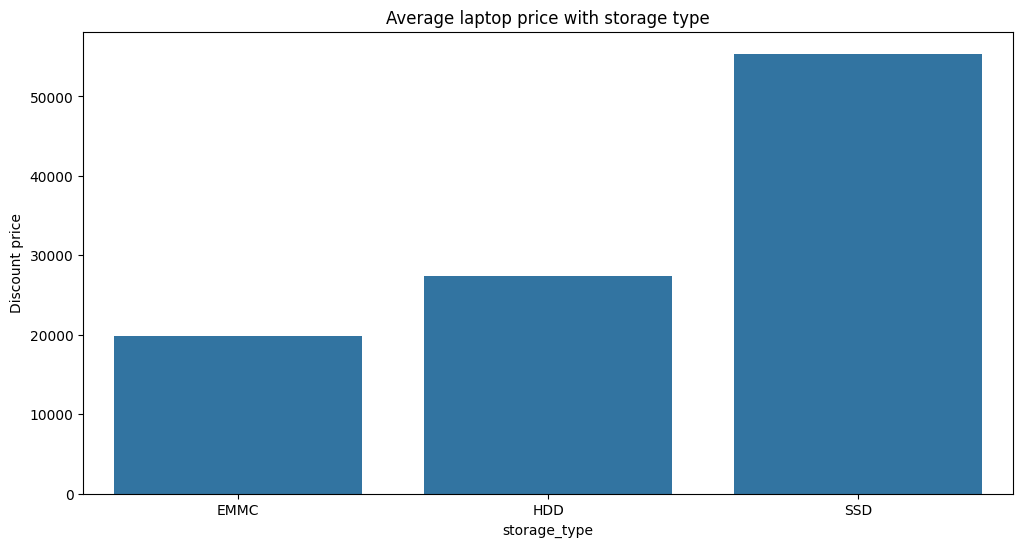

In [40]:
plt.figure(figsize=(12,6))

# Use Bar plot to show which storage type average selling price is high
sns.barplot(data=avg_laptop_price_with_storageType, x="storage_type", y="Discount price")

# Add title
plt.title("Average laptop price with storage type");

**Comments:**

We observe that from above figure that laptops having SSD storage type is high in price.

### Relationship between actual price and discount price.

Text(0.5, 1.0, 'Scatter plot between Actual price and Discount price')

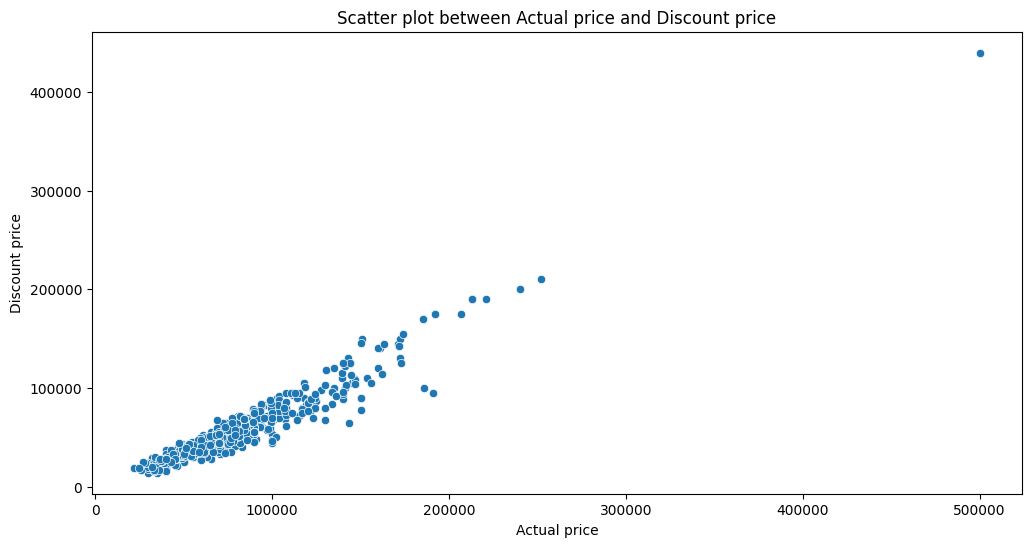

In [41]:
plt.figure(figsize=(12,6))
# Use scatter plot to see the relationship between actual price and discount price
sns.scatterplot(data=df, x="Actual price", y="Discount price")

# Add title
plt.title("Scatter plot between Actual price and Discount price")

**Comments:** 

From the figure it is cleary seen that there is a strong relationship between Actual price and Discount price. How many strong? Let's find the correlation between them.

In [42]:
corr_val = df["Actual price"].corr(df["Discount price"])
corr_val

np.float64(0.9601848577442852)

**Comments:**

we calculate the correlation coefficient. The correlation coefficient between Actual price and Discount price is 0.9602, i.e., they are positively correlated also.

### Average laptop price with processor tiers and brands
Now we are interested to find with in each brand how price fall as processor tier decreases.

In [43]:
# Store df into df_processor dataframe
df_processor = df

# Define a function
def assign_processor_tier(cpu):
    if pd.isna(cpu):
        return None
    cpu = cpu.lower()
    if 'core i3' in cpu or 'ryzen 3' in cpu or 'pentium' in cpu or 'celeron' in cpu:
        return 'Entry'
    elif 'core i5' in cpu or 'ryzen 5' in cpu:
        return 'Mid'
    elif 'core i7' in cpu or 'ryzen 7' in cpu:
        return 'High'
    elif 'core i9' in cpu or 'ryzen 9' in cpu or 'core ultra' in cpu:
        return 'Ultra'
    else:
        return 'Other'

# Apply to our DataFrame
df_processor['processor_tier'] = df_processor['processor'].apply(assign_processor_tier)

# Display first 3 observation
df_processor.head(3)

,Product Name,ProductID,Actual price,Discount price,Stars,Rating,Reviews,Description,Link,discount_pct(%),brand,processor,ram_gb,storage_gb,storage_type,processor_tier
0,MSI Cyborg 15 Intel Core i5 12th Gen 12450H - ...,COMGZW35W3DSJADN,89990.0,54990.0,3.9,7 Ratings,1 Reviews,Intel Core i5 Processor (12th Gen)16 GB DDR5 R...,https://www.flipkart.com/msi-cyborg-15-intel-c...,38.89,MSI,Intel Core i5 12th Gen 12450H,16.0,512.0,SSD,Mid
1,MSI Thin 15 Intel Core i7 12th Gen 12650H - (8...,COMGZW37ZX66DBHF,83990.0,67990.0,NIL,NIL,NIL,Intel Core i7 Processor (12th Gen)8 GB DDR4 RA...,https://www.flipkart.com/msi-thin-15-intel-cor...,19.05,MSI,Intel Core i7 12th Gen 12650H,8.0,1024.0,SSD,High
2,DELL Inspiron 3520 Intel Core i3 12th Gen 1215...,COMGJ75HJGFDJ6JN,49240.0,35660.0,4.2,"1,805 Ratings",143 Reviews,Intel Core i3 Processor (12th Gen)8 GB DDR4 RA...,https://www.flipkart.com/dell-inspiron-3520-in...,27.58,DELL,Intel Core i3 12th Gen 1215U,8.0,512.0,SSD,Entry


In [44]:
# Check unique values counts
df_processor['processor_tier'].value_counts()

processor_tier
Mid      364
Entry    305
High     181
Ultra     46
Other     27
Name: count, dtype: int64

In [45]:
processor_tier_price = df_processor.groupby(["brand", "processor_tier"])["Discount price"].mean().sort_values(ascending=False).reset_index()
processor_tier_price

,brand,processor_tier,Discount price
0,ASUS,Ultra,155171.818182
1,SAMSUNG,Ultra,144990.000000
2,MSI,Ultra,141590.000000
3,SAMSUNG,High,117990.000000
4,Acer,High,97336.923077
5,DELL,Ultra,94990.000000
6,Acer,Ultra,94990.000000
7,HP,Ultra,93406.666667
8,DELL,High,92256.666667
9,Lenovo,Ultra,90990.000000


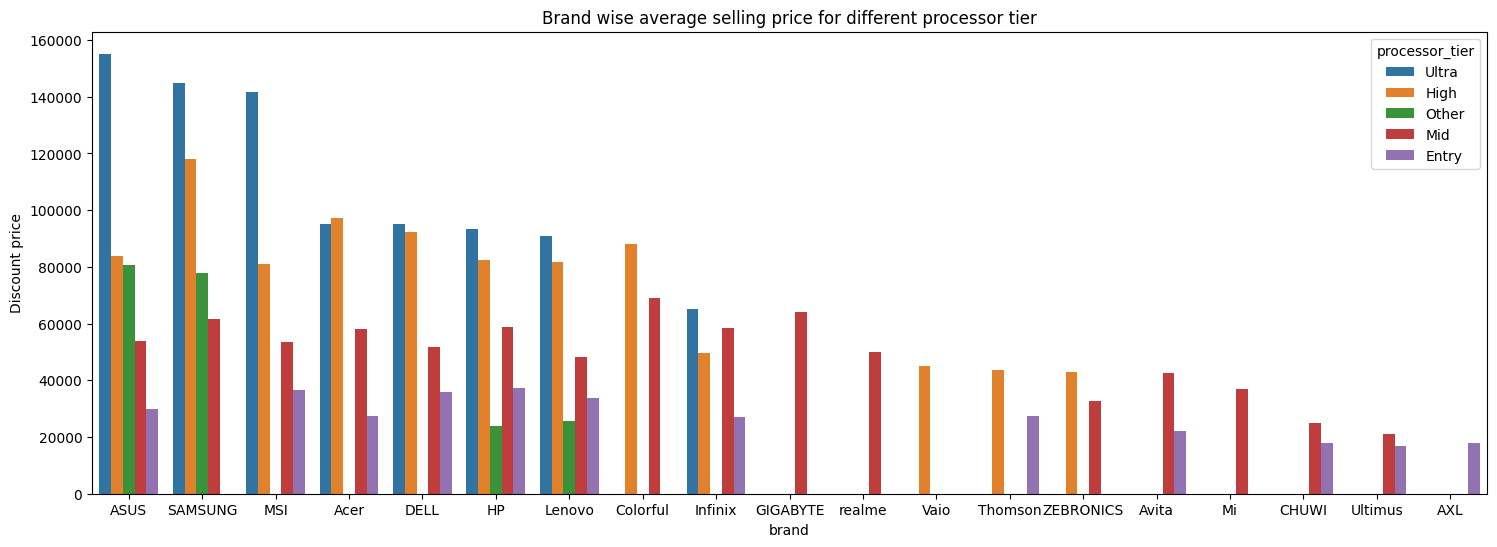

In [46]:
plt.figure(figsize=(18,6))

# Use bar plot to see Brand wise average selling price for different processor tier
sns.barplot(processor_tier_price, x="brand", hue="processor_tier", y="Discount price")

# Add title
plt.title("Brand wise average selling price for different processor tier");

**Comments:**

We can see that ASUS, SAMSUNG, MSI Brands has higher average selling price for different level of processor tier and price decreases as processor tier decreases. But for Acer, DELL, HP, Lenevo brands has approximately same type of average actual selling price for processor tier and price approximately decreases as processor tier decreases. And for other brands like Colorful, Infinix, GIGABYTE, realme, Vaio average selling price gradually decreases.

#### Discount Analysis

Now we are trying to find which brands offer the highest level of discount.

In [47]:
discout_brand = df.groupby(["brand"])["discount_pct(%)"].mean().sort_values(ascending=True).reset_index()
discout_brand

,brand,discount_pct(%)
0,SAMSUNG,18.002727
1,HP,23.111195
2,MSI,25.613895
3,ASUS,28.701913
4,Acer,29.550741
5,Colorful,30.928333
6,realme,31.055000
7,DELL,31.678293
8,Lenovo,33.488421
9,Infinix,34.512000


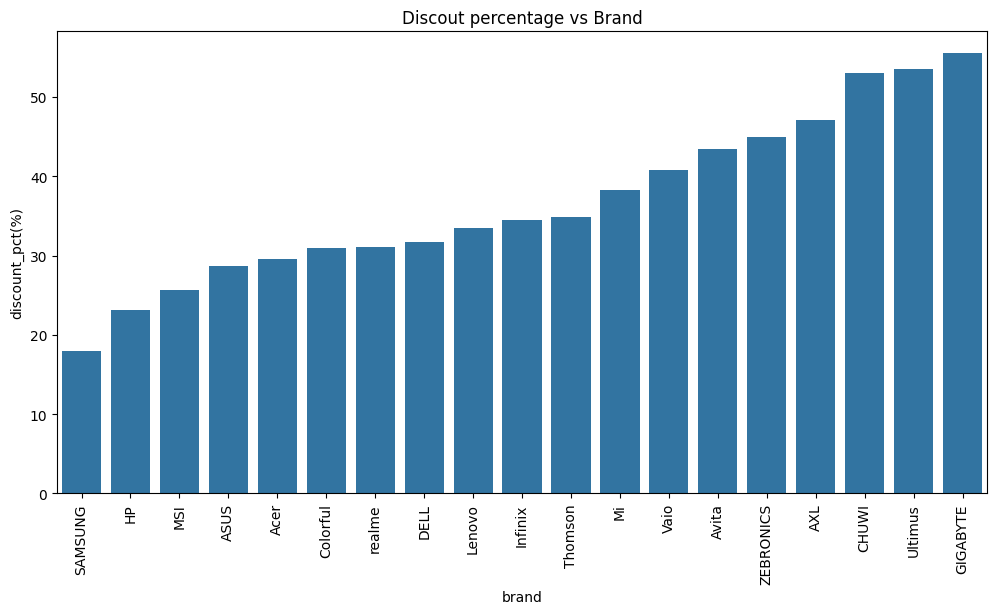

In [48]:
plt.figure(figsize=(12,6))
# Use bar plot to see which brand discout more than others
sns.barplot(discout_brand, x="brand", y="discount_pct(%)")
# Add title
plt.title("Discout percentage vs Brand")
# Add xticks
plt.xticks(rotation=90);

**Comments:**

From the above figure it is clear that `SAMSUNG, HP, MSI, ASUS` brands give us less discount and `CHUWI, Ultimus, GIGABYTE` brands gives us higher discounts than others.

**Now try to find which brand or brands gives us discount more than 50%.**

In [49]:
discout_more_than_50 = discout_brand[discout_brand["discount_pct(%)"] > 50]
discout_more_than_50

,brand,discount_pct(%)
16,CHUWI,53.020
17,Ultimus,53.565
18,GIGABYTE,55.470


**Comments:**

From the abve data frame it is seen that `CHUWI, Ultimus, GIGABYTE` brands gives more than 50% discount.

## Market Segmentation

In [50]:
df.describe()

,Actual price,Discount price,discount_pct(%),ram_gb,storage_gb
count,923.000000,923.000000,923.000000,923.000000,923.000000
mean,75354.066089,54495.817985,28.845330,11.813651,553.152763
std,36051.320904,31239.227218,9.862427,5.011045,218.346988
min,21990.000000,13990.000000,0.670000,4.000000,32.000000
25%,51967.000000,35990.000000,21.715000,8.000000,512.000000
50%,69890.000000,47990.000000,28.110000,8.000000,512.000000
75%,88990.000000,63990.000000,36.165000,16.000000,512.000000
max,499990.000000,439990.000000,60.020000,64.000000,2048.000000


In [51]:
low, mid = [55000, 80000]
print(low, mid)

55000 80000


In [52]:
# Srore df into df_price_tier
df_price_tier = df
# Define function
def budget_range(price):

    if (price <= low):
        return "budget"
    elif (price <= mid):
        return "mid range"
    else:
        return "premium"
# Create a new column
df_price_tier["price_tier"] = df_price_tier["Discount price"].apply(budget_range)

# Display the dataframe with 5 observations
df_price_tier.head(3)

,Product Name,ProductID,Actual price,Discount price,Stars,Rating,Reviews,Description,Link,discount_pct(%),brand,processor,ram_gb,storage_gb,storage_type,processor_tier,price_tier
0,MSI Cyborg 15 Intel Core i5 12th Gen 12450H - ...,COMGZW35W3DSJADN,89990.0,54990.0,3.9,7 Ratings,1 Reviews,Intel Core i5 Processor (12th Gen)16 GB DDR5 R...,https://www.flipkart.com/msi-cyborg-15-intel-c...,38.89,MSI,Intel Core i5 12th Gen 12450H,16.0,512.0,SSD,Mid,budget
1,MSI Thin 15 Intel Core i7 12th Gen 12650H - (8...,COMGZW37ZX66DBHF,83990.0,67990.0,NIL,NIL,NIL,Intel Core i7 Processor (12th Gen)8 GB DDR4 RA...,https://www.flipkart.com/msi-thin-15-intel-cor...,19.05,MSI,Intel Core i7 12th Gen 12650H,8.0,1024.0,SSD,High,mid range
2,DELL Inspiron 3520 Intel Core i3 12th Gen 1215...,COMGJ75HJGFDJ6JN,49240.0,35660.0,4.2,"1,805 Ratings",143 Reviews,Intel Core i3 Processor (12th Gen)8 GB DDR4 RA...,https://www.flipkart.com/dell-inspiron-3520-in...,27.58,DELL,Intel Core i3 12th Gen 1215U,8.0,512.0,SSD,Entry,budget


In [53]:
df_price_tier["price_tier"].value_counts(normalize=True)

price_tier
budget       0.686891
mid range    0.196100
premium      0.117010
Name: proportion, dtype: float64

**Comments:**

From the above series, we observe that more laptops within budget range (<=55000>) solded out.

### what are the average price, discount and features make up of each segment.

In [66]:
# Apply groupby to find which price tier gives more discounts
discount_price_tier = df_price_tier.groupby(["price_tier"])["discount_pct(%)"].mean().reset_index()
# Display dataframe
discount_price_tier

,price_tier,discount_pct(%)
0,budget,31.680962
1,mid range,24.649669
2,premium,19.230741


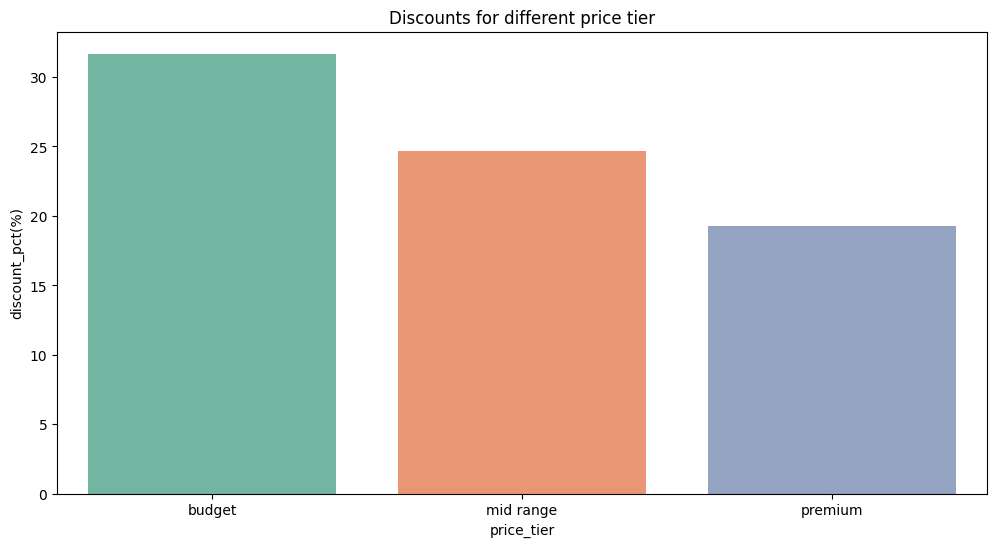

In [67]:
plt.figure(figsize=(12,6))
# Use bar plot to show which price tier gives more discounts
sns.barplot(discount_price_tier, x="price_tier", y="discount_pct(%)", hue="price_tier", palette="Set2")
# Add title
plt.title("Discounts for different price tier");

**Comments:**

From the above figure we can observe that **budget price range** give more discount.

#### Price tier VS ram

In [68]:
## Apply groupby to find for different price tier different gb ram
data_ram = df.groupby(["price_tier"])["ram_gb"].value_counts().reset_index()
# Display dataframe
data_ram 

,price_tier,ram_gb,count
0,budget,8.0,403
1,budget,16.0,199
2,budget,4.0,32
3,mid range,16.0,120
4,mid range,8.0,59
5,mid range,12.0,2
6,premium,16.0,93
7,premium,32.0,10
8,premium,24.0,3
9,premium,8.0,1


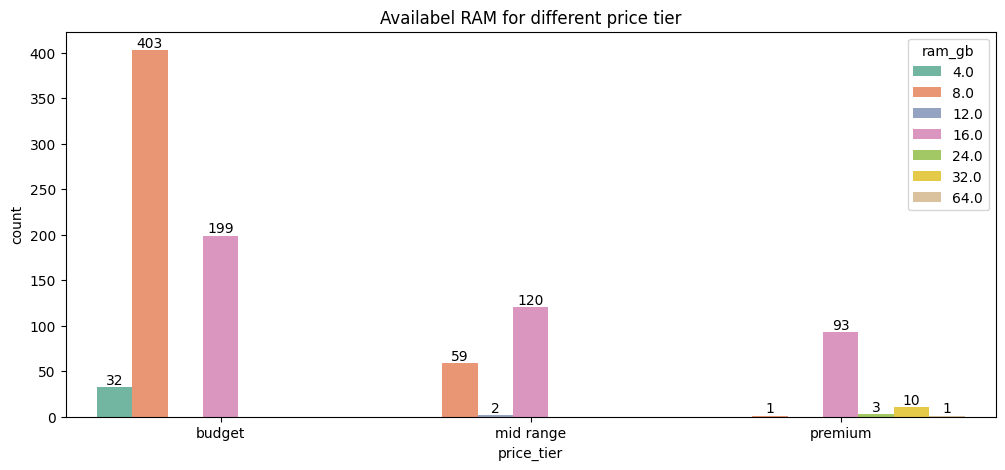

In [69]:
plt.figure(figsize=(12,5))
# Use bar plot to show different gb ram for every price tier
ax = sns.barplot(data_ram, x="price_tier", y="count", hue="ram_gb", palette='Set2')
# Add title
plt.title("Availabel RAM for different price tier")
# Add label
for container in ax.containers:
    ax.bar_label(container)
plt.show()

**Comments:**

From the above figure it is clear that, in budget range there are more laptop with **8GB RAM**, in mid range there are more laptops with **16GB RAM** and in premium range that is **16GB**.

#### Price tier VS Storage

In [70]:
data_storage = df.groupby(["price_tier"])["storage_gb"].value_counts().reset_index()

data_storage 

,price_tier,storage_gb,count
0,budget,512.0,519
1,budget,256.0,79
2,budget,1024.0,16
3,budget,128.0,10
4,budget,64.0,9
5,budget,32.0,1
6,mid range,512.0,118
7,mid range,1024.0,57
8,mid range,256.0,6
9,premium,1024.0,57


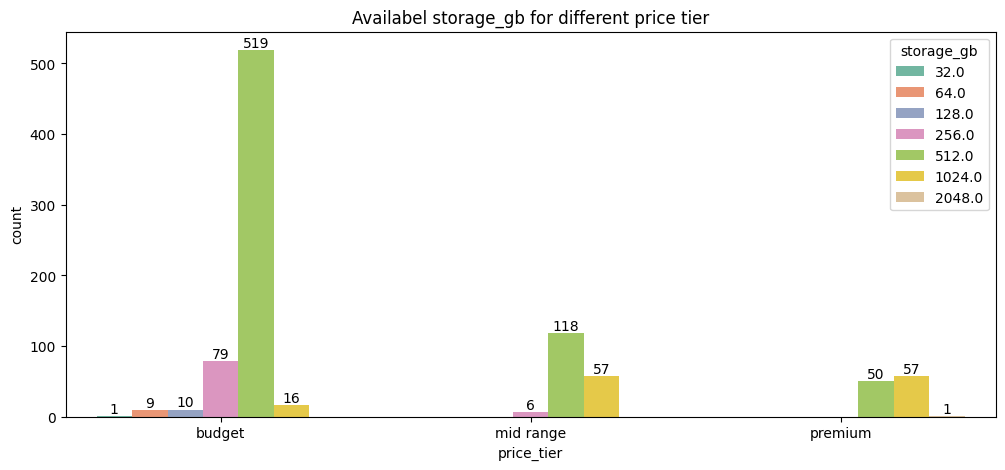

In [72]:
plt.figure(figsize=(12,5))
ax = sns.barplot(data_storage, x="price_tier", y="count", hue="storage_gb", palette='Set2')

# Add title
plt.title("Availabel storage_gb for different price tier")

# Add label
for container in ax.containers:
    ax.bar_label(container)
    
plt.show()

**Comments:**

From above figure we can observe that, all types of storage available in budget range except 2048 GB. 512 gb storage is more avalibale for budget and mid range laptop and for premium that is 1024 gb.

#### Price tier with storage type

In [73]:
# Apply groupby to find for different price tier different storage type
data_storage_type = df_price_tier.groupby(["price_tier"])["storage_type"].value_counts().reset_index()
# Display dataframe
data_storage_type 

,price_tier,storage_type,count
0,budget,SSD,609
1,budget,EMMC,15
2,budget,HDD,10
3,mid range,SSD,181
4,premium,SSD,108


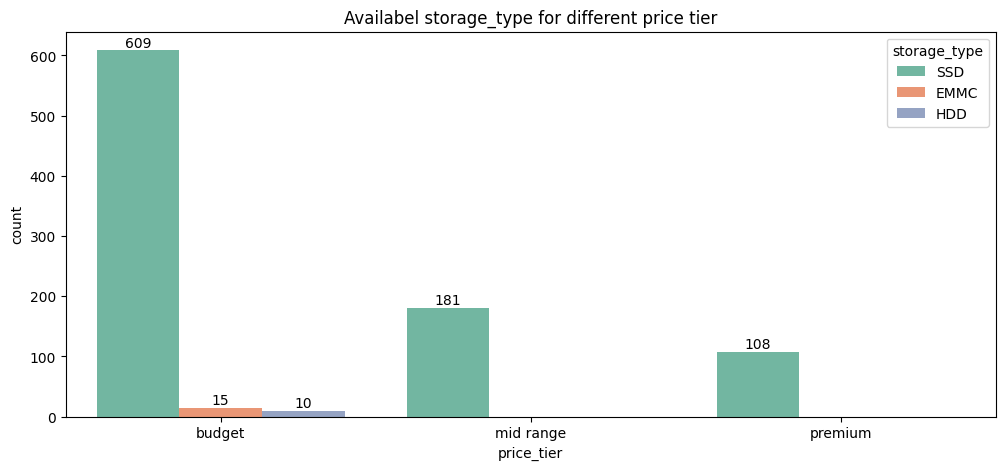

In [74]:
plt.figure(figsize=(12,5))

# Use bar plot to show different gb ram for every price tier
ax = sns.barplot(data_storage_type, x="price_tier", y="count", hue="storage_type", palette='Set2')

# Add title
plt.title("Availabel storage_type for different price tier")

# Add label
for container in ax.containers:
    ax.bar_label(container)
plt.show()

**Comments:**

From above figure we can observe that, only budget range has different type of storage and others has only SSD type.

#### Price tier VS Processor tier

In [75]:
# Apply groupby to find for different price tier for different processor_tier
data_processor_type = df_price_tier.groupby(["price_tier"])["processor_tier"].value_counts().reset_index()
# Display dataframe
data_processor_type 

,price_tier,processor_tier,count
0,budget,Entry,304
1,budget,Mid,265
2,budget,High,56
3,budget,Other,9
4,mid range,Mid,90
5,mid range,High,62
6,mid range,Ultra,15
7,mid range,Other,13
8,mid range,Entry,1
9,premium,High,63


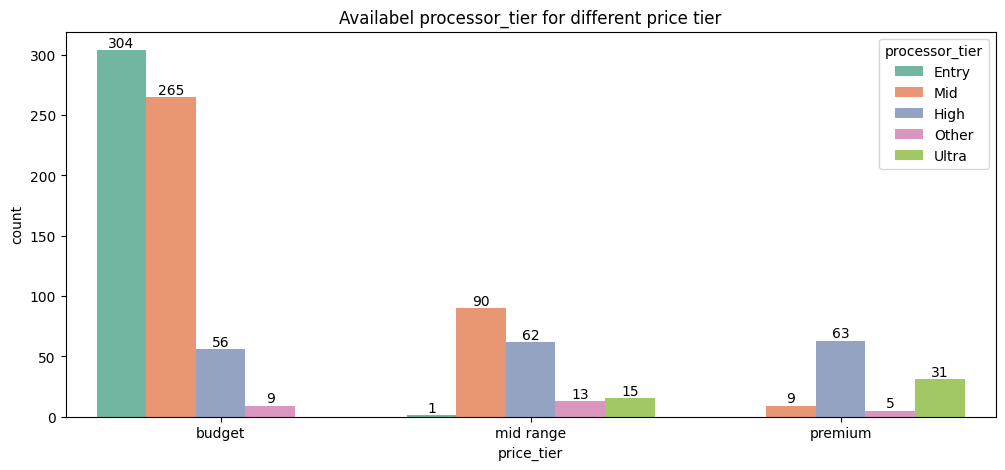

In [76]:
plt.figure(figsize=(12,5))

# Use bar plot to show different processor_tier for every price tier
ax = sns.barplot(data_processor_type , x="price_tier", y="count", hue="processor_tier", palette='Set2')

# Add title
plt.title("Availabel processor_tier for different price tier")

# Add label
for container in ax.containers:
    ax.bar_label(container)
plt.show()

**Comments:**

From above figure we can observe that, budget range has high entry level of processor, mid range has mid level of processor, Premium range has more high level of processor.

## Customer centric metric

In [77]:
# Convert Ratings column object into float
df_price_tier["Rating"] = df_price_tier["Rating"].str.replace("Ratings", "", regex=True).str.replace(",", "").str.replace("NIL", "0").astype(float)
# Display Ratings column
df_price_tier["Rating"] 

0         7.0
1         0.0
2      1805.0
3      6977.0
4      1263.0
        ...  
954     508.0
955     108.0
957    3897.0
958      53.0
959    5540.0
Name: Rating, Length: 923, dtype: float64

In [78]:
# Convert Ratings column object into float
df_price_tier["Reviews"] = df_price_tier["Reviews"].str.replace("Reviews", "", regex=True).str.replace(",", "").str.replace("NIL", "0").astype(float)
# Display Ratings column
df_price_tier["Reviews"] 

0        1.0
1        0.0
2      143.0
3      596.0
4      113.0
       ...  
954     77.0
955     16.0
957    457.0
958      5.0
959    485.0
Name: Reviews, Length: 923, dtype: float64

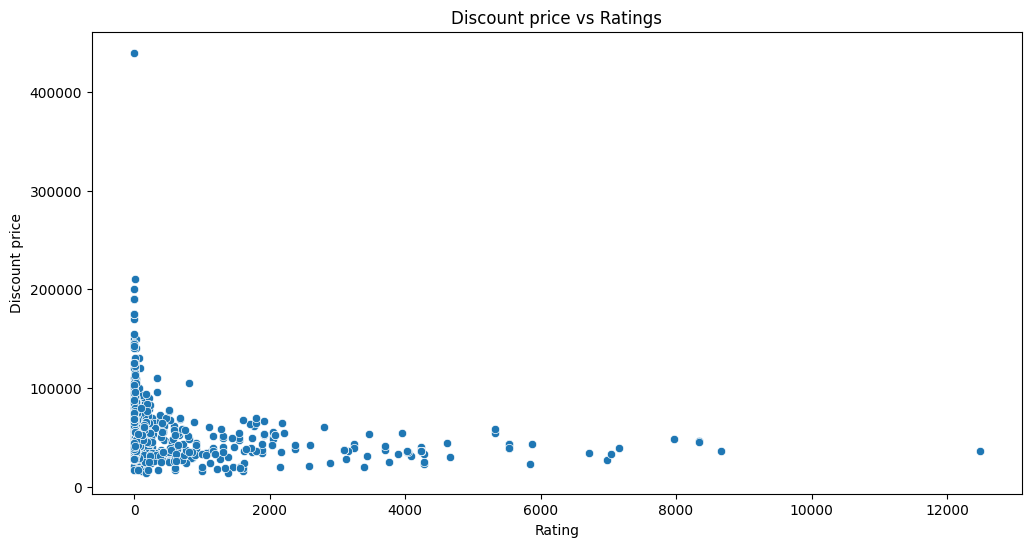

In [79]:
plt.figure(figsize=(12,6))
# Use Scatterplot to visulaize the relationship between Discount price and Ratings
sns.scatterplot(df_price_tier, x='Rating', y='Discount price')
# Add title
plt.title("Discount price vs Ratings");

In [80]:
df_price_tier["Rating"].corr(df["Discount price"])

np.float64(-0.26367201057164164)

**Comments:**

It is clear that Discount price and Ratings are negatively correlated, i.e., when price are increases ratings are decreases.

In [81]:
# Most rated brand
df_rate_brand = df_price_tier.groupby(['brand'])["Rating"].mean().sort_values(ascending=False).reset_index()
df_rate_brand

,brand,Rating
0,realme,4317.000000
1,HP,2188.615044
2,Lenovo,1153.409357
3,Avita,1095.000000
4,ASUS,1081.426087
5,Infinix,976.300000
6,Mi,550.000000
7,Acer,525.407407
8,ZEBRONICS,404.571429
9,SAMSUNG,389.818182


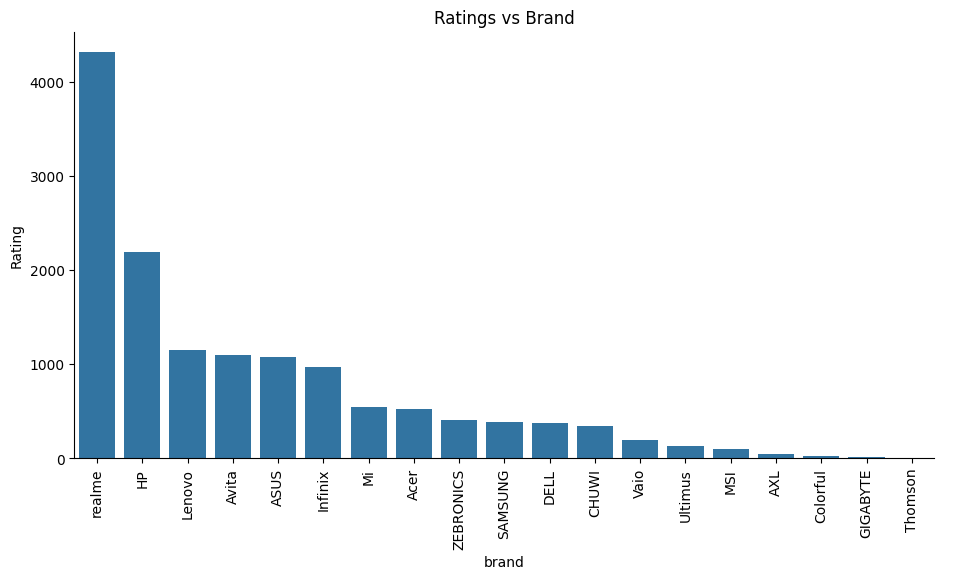

In [84]:
# Use Catplot to show Ratings for different brand
sns.catplot(df_rate_brand, x="brand", y="Rating", kind="bar", height=5, aspect=1.9)
# Add title
plt.title("Ratings vs Brand")
# Add xticks
plt.xticks(rotation=90);

**Comments:**

From the above figure we can say that, `realme, HP, Lenovo, Avita, Asus` are all more rated brand.

Let's find a higher-rated laptop with a higher discount or actual selling price.

In [85]:
# Higher rated laptops discount percentage
df_rate_discount = df_price_tier.groupby(['Rating'])["discount_pct(%)"].mean().sort_index(ascending=False).reset_index()
# Display dataframe
df_rate_discount[:20]

,Rating,discount_pct(%)
0,12482.0,24.280000
1,8671.0,28.390000
2,8333.0,30.025000
3,7975.0,31.430000
4,7151.0,27.610000
5,7038.0,37.700000
6,6977.0,38.660000
7,6722.0,39.110000
8,5880.0,32.340000
9,5849.0,31.830000


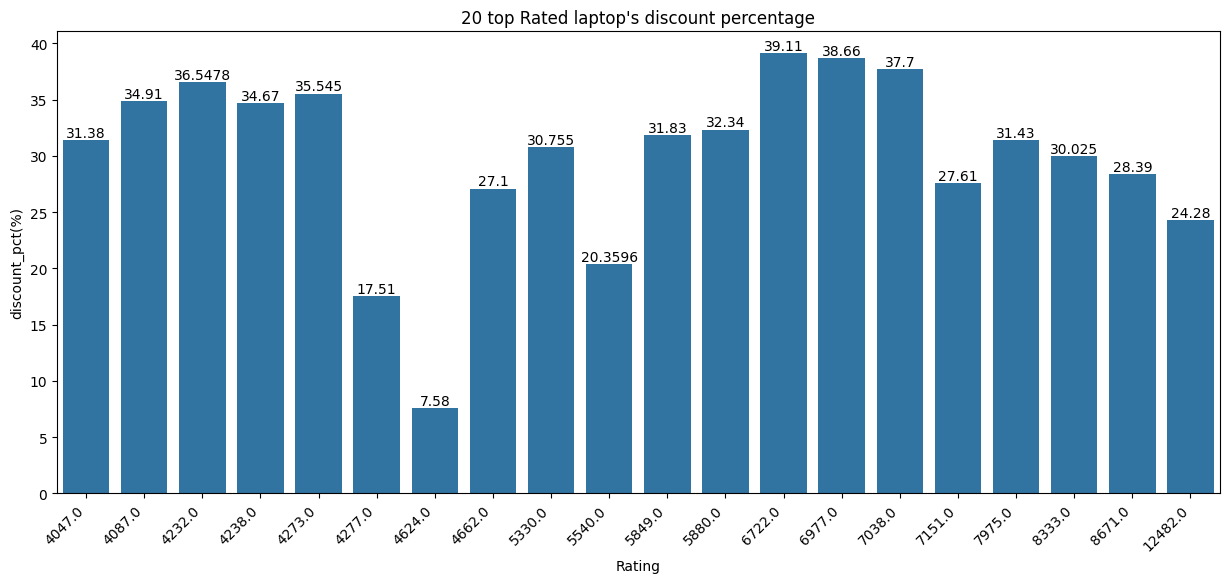

In [86]:
plt.figure(figsize=(15,6))
# Use Catplot to show 20 top Rated laptop's discount percentage
ax = sns.barplot(df_rate_discount[:20], x="Rating", y="discount_pct(%)")
# Add label
for container in ax.containers:
    ax.bar_label(container)
# Add title
plt.title("20 top Rated laptop's discount percentage")
# Add xticks
plt.xticks(rotation=45, ha="right");

In [87]:
# Higher rated laptops actual selling price
df_rate_price = df_price_tier.groupby(['Rating'])["Discount price"].mean().sort_index(ascending=False).reset_index()
# Display dataframe
df_rate_price

,Rating,Discount price
0,12482.0,35800.000000
1,8671.0,35800.000000
2,8333.0,45269.500000
3,7975.0,47999.000000
4,7151.0,39490.000000
...,...,...
279,4.0,75989.846154
280,3.0,38815.957895
281,2.0,52745.000000
282,1.0,58990.000000


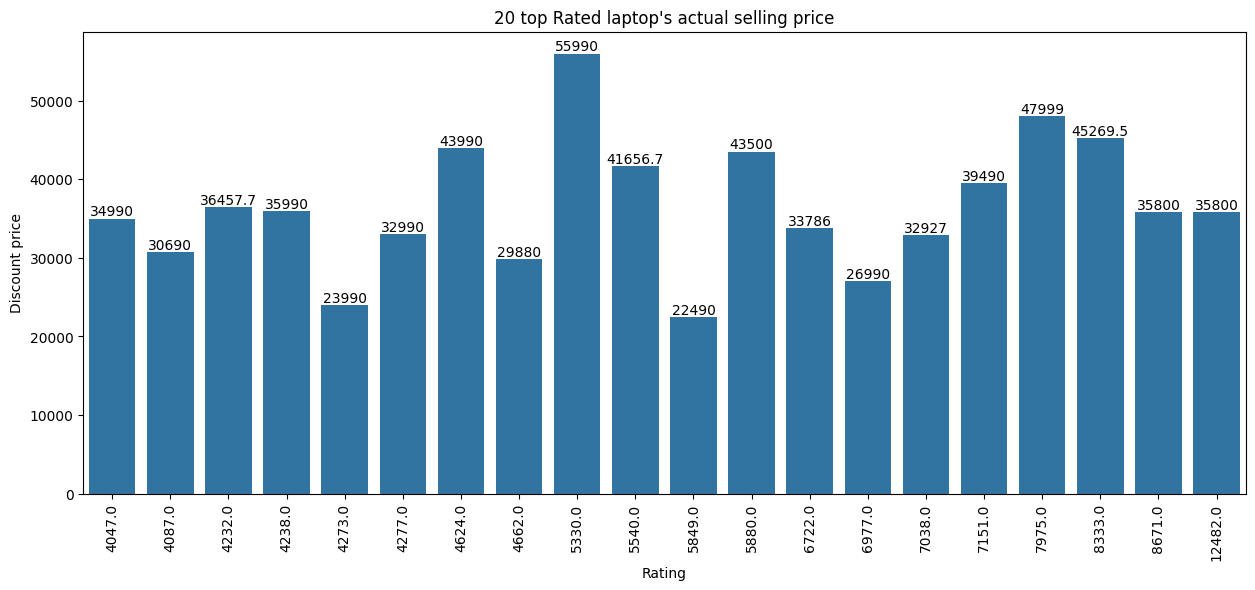

In [88]:
plt.figure(figsize=(15,6))
# Use Catplot to show 20 top Rated laptop's actual selling price
ax = sns.barplot(df_rate_price[:20], x="Rating", y="Discount price")
# Add label
for container in ax.containers:
    ax.bar_label(container)
# Add title
plt.title("20 top Rated laptop's actual selling price")
# Add xticks
plt.xticks(rotation=90);

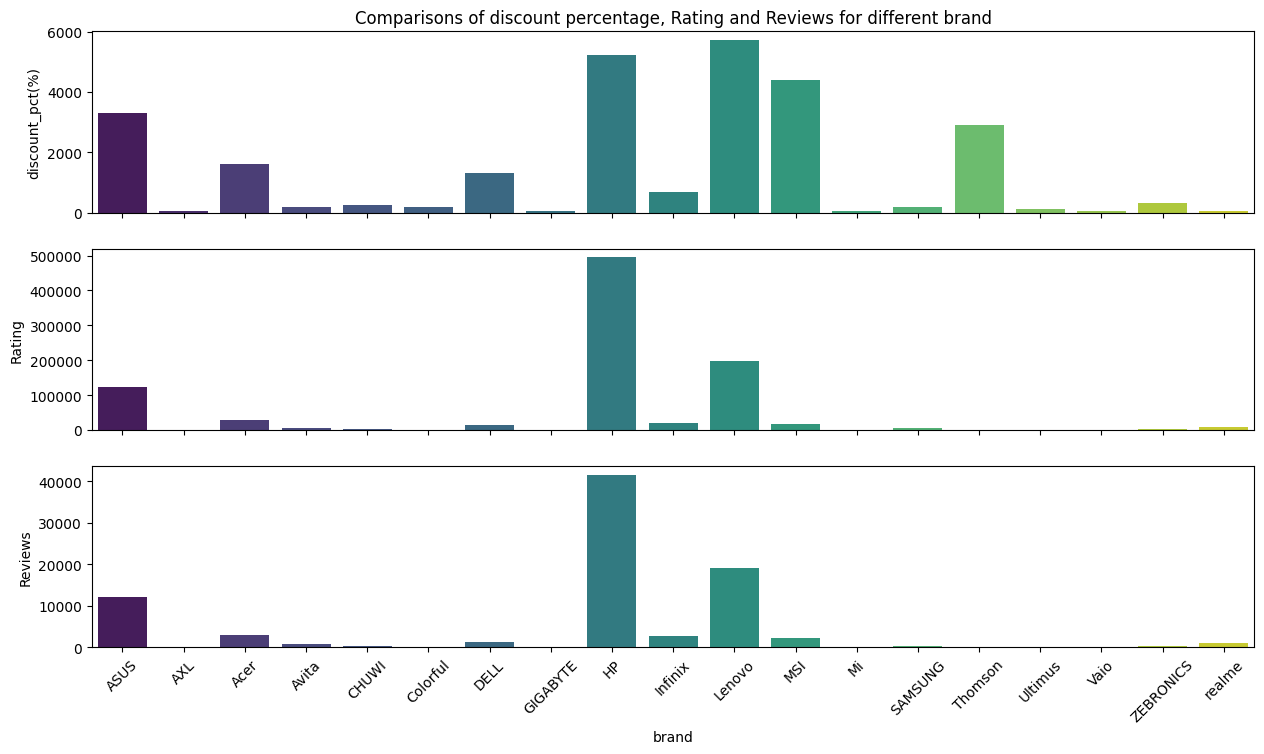

In [89]:
# Create a list 
discount_rate_review = ["discount_pct(%)", "Rating", "Reviews"]
# Create a figure object and axes (1d array)
fig, axes = plt.subplots(3, 1, sharex=True, figsize=(15,8))
# Create a variable and assign value with 0
l=0

for x in discount_rate_review:
    # Create  dataframe
    data_drr = df_price_tier.groupby(["brand"])[x].sum().reset_index()
    
    sns.barplot(data=data_drr, x="brand", y=x, ax=axes[l], hue="brand", palette="viridis")
    # Add xticks
    plt.xticks(rotation=45)
    # Increament value by 1
    l = l+1
# Add title
axes[0].set_title("Comparisons of discount percentage, Rating and Reviews for different brand");

**Comments:**

From the above figure we can say that, `HP` laptops brand give higher discount but not more than higher `Lenovo` and has more ratings and review than other laptops.

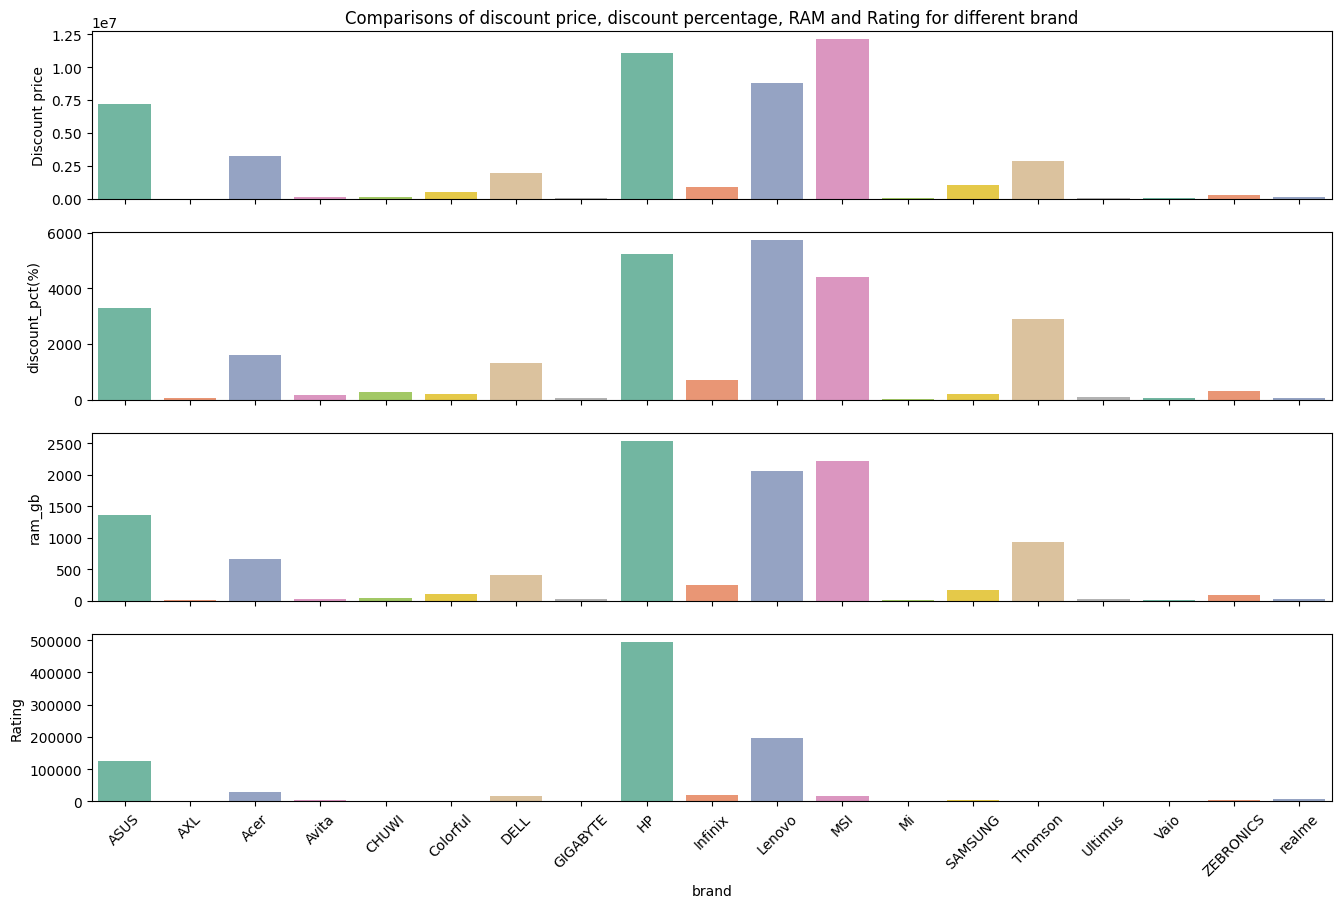

In [90]:
# Create a list 
price_discount_ram_rate = ["Discount price", "discount_pct(%)", "ram_gb", "Rating"]
# Create a figure object and axes (1d array)
fig, axes = plt.subplots(4, 1, sharex=True, figsize=(16,10))
# Create a variable and assign value with 0
l=0

for x in price_discount_ram_rate:
    # Create  dataframe
    data_drr = df_price_tier.groupby(["brand"])[x].sum().reset_index()
    
    sns.barplot(data=data_drr, x="brand", y=x, ax=axes[l], hue="brand", palette="Set2")
    # Add xticks
    plt.xticks(rotation=45)
    # Increament value by 1
    l = l+1
# Add title
axes[0].set_title("Comparisons of discount price, discount percentage, RAM and Rating for different brand");

In [ ]:
# df.to_excel("Flipcart-Laptop-Clean-Data.xlsx", index=False)